# Forecasting

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import numpy as np

In [2]:
con = duckdb.connect(':memory:')

In [ ]:
nodes_df = con.execute("""
    SELECT *
    FROM read_csv_auto('../datasets/cloud_energy_consumption/processed_nodes/*.csv',
                       filename=true,
                       union_by_name=true)
""").df()

node_groups = pd.read_csv('../datasets/cloud_energy_consumption/node-groups/2024-12-14T000000Z_2025-04-13T235959Z/cleaned_node_groups.csv')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
nodes_df.shape

(7176000, 42)

In [5]:
node_groups.head()

,node_group,form_factor,total_cores,total_threads,cpu_freq_ghz,#gpus,#disks,#ethernet_nics,#infiniband_nics,disk_size_gb,memory_size_gb,memory_used_slots,rated_power_total,rated_power_usable
0,11cdff15,Blade Server,24,48,2.7,0,1,2,0,400.00,16.0,1,3200.0,1600.0
1,b8994569,Chassis Server,48,96,2.1,0,1,2,0,480.00,192.0,6,2000.0,2000.0
2,a97fe24e,Rack Server,40,80,2.1,0,2,2,0,223.50,768.0,12,750.0,750.0
3,5f67cb23,Rack Server,40,80,2.1,2,2,2,1,1966.08,192.0,12,1600.0,1600.0
4,f6fec747,Chassis Server,48,96,2.2,0,4,2,0,446.63,192.0,6,2400.0,2400.0


In [6]:
print(nodes_df.columns)

Index(['timestamp', 'node_name', 'node_group', 'cpu_usage_percent',
       'cpu_idle_percent', 'cpu_nice_percent', 'cpu_interrupt_percent',
       'cpu_softirq_percent', 'cpu_steal_percent', 'cpu_system_percent',
       'cpu_user_percent', 'cpu_wait_percent', 'load_shortterm_percent',
       'load_midterm_percent', 'load_longterm_percent', 'num_processes_total',
       'num_processes_blocked', 'num_processes_paging',
       'num_processes_running', 'num_processes_sleeping',
       'num_processes_stopped', 'num_processes_zombie', 'memory_total_bytes',
       'memory_free_bytes', 'memory_used_bytes', 'memory_buffered_bytes',
       'memory_cached_bytes', 'memory_slab_recl_bytes',
       'memory_slab_unrecl_bytes', 'disk_total_bytes', 'disk_free_bytes',
       'disk_used_bytes', 'disk_reserved_bytes', 'network_bw_rx_b/s',
       'network_bw_tx_b/s', 'ipmi_system_power_watts',
       'rapl_power_total_watts', 'scaphandre_power_total_watts',
       'ipmi_system_power_watts_imputed', 'rapl_p

In [7]:
# first will aggreggate timestamps into daily counts
nodes_df['timestamp'] = pd.to_datetime(nodes_df['timestamp'], utc=True)
nodes_df['date'] = nodes_df['timestamp'].dt.date


0          2024-12-14
1          2024-12-14
2          2024-12-14
3          2024-12-14
4          2024-12-14
              ...    
7175995    2025-04-13
7175996    2025-04-13
7175997    2025-04-13
7175998    2025-04-13
7175999    2025-04-13
Name: date, Length: 7176000, dtype: object


In [9]:
avg_cols = [
    'cpu_usage_percent', 'cpu_user_percent', 'cpu_idle_percent',
    'cpu_system_percent', 'cpu_wait_percent', 'cpu_nice_percent',
    'cpu_interrupt_percent', 'cpu_softirq_percent', 'cpu_steal_percent',
    'load_shortterm_percent', 'load_midterm_percent', 'load_longterm_percent',
    'memory_used_bytes', 'memory_free_bytes', 'memory_cached_bytes',
    'memory_buffered_bytes', 'memory_slab_recl_bytes', 'memory_slab_unrecl_bytes',
    'num_processes_total', 'num_processes_running', 'num_processes_sleeping',
    'num_processes_blocked', 'num_processes_zombie', 'num_processes_stopped',
    'disk_used_bytes', 'disk_free_bytes', 'disk_reserved_bytes',
]

sum_cols = ['network_bw_rx_b/s', 'network_bw_tx_b/s']

power_cols = ['ipmi_system_power_watts_imputed', 'rapl_power_total_watts_imputed', 'scaphandre_power_total_watts_imputed']

static_cols = ['memory_total_bytes','disk_total_bytes']

In [10]:
daily_df = nodes_df.groupby(['node_name', 'node_group', 'date']).agg(
    **{col: (col, 'mean') for col in avg_cols + power_cols},
    **{col: (col, 'sum') for col in sum_cols},
    **{col: (col, 'first') for col in static_cols},
    n_readings=('timestamp', 'count'), 
).reset_index()

In [11]:
daily_df.head(30)

,node_name,node_group,date,cpu_usage_percent,cpu_user_percent,cpu_idle_percent,cpu_system_percent,cpu_wait_percent,cpu_nice_percent,cpu_interrupt_percent,...,disk_free_bytes,disk_reserved_bytes,ipmi_system_power_watts_imputed,rapl_power_total_watts_imputed,scaphandre_power_total_watts_imputed,network_bw_rx_b/s,network_bw_tx_b/s,memory_total_bytes,disk_total_bytes,n_readings
0,0049db0c,a6177608,2024-12-14,0.239000,0.181729,99.761000,0.054500,0.000104,0.001292,0.0,...,4.941998e+11,7.983950e+08,414.012313,267.527021,0.0,2.040027e+09,2.048919e+08,4.054358e+11,9.596182e+11,480
1,0049db0c,a6177608,2024-12-15,0.238625,0.183250,99.761375,0.052917,0.000583,0.001000,0.0,...,4.942687e+11,7.983514e+08,413.039958,266.396083,0.0,1.227629e+09,3.733599e+08,4.054358e+11,9.596182e+11,480
2,0049db0c,a6177608,2024-12-16,0.232375,0.174896,99.767625,0.054688,0.000083,0.001167,0.0,...,4.942919e+11,7.982429e+08,413.095104,266.506792,0.0,3.138897e+10,5.616728e+08,4.054358e+11,9.596182e+11,480
3,0049db0c,a6177608,2024-12-17,0.231333,0.174042,99.768667,0.054750,0.000063,0.001188,0.0,...,4.942817e+11,7.982544e+08,414.310729,267.535896,0.0,1.655317e+09,4.643816e+08,4.054358e+11,9.596182e+11,480
4,0049db0c,a6177608,2024-12-18,0.240917,0.179833,99.759083,0.057354,0.000292,0.002167,0.0,...,4.942695e+11,7.985574e+08,417.546542,268.925583,0.0,2.595751e+09,1.724964e+09,4.054358e+11,9.596182e+11,480
5,0049db0c,a6177608,2024-12-19,0.237000,0.179333,99.763000,0.054917,0.000146,0.001375,0.0,...,4.942569e+11,7.986792e+08,415.850542,268.601583,0.0,3.509946e+10,4.675655e+08,4.054358e+11,9.596182e+11,480
6,0049db0c,a6177608,2024-12-20,0.233083,0.174937,99.766917,0.056104,0.000083,0.001375,0.0,...,4.942478e+11,7.987751e+08,415.128625,268.724958,0.0,1.890572e+09,1.464771e+09,4.054358e+11,9.596182e+11,480
7,0049db0c,a6177608,2024-12-21,0.227917,0.170688,99.772083,0.054875,0.000167,0.001375,0.0,...,4.942383e+11,7.985783e+08,415.152750,268.907938,0.0,2.421764e+09,8.893693e+08,4.054358e+11,9.596182e+11,480
8,0049db0c,a6177608,2024-12-22,0.225958,0.169333,99.774042,0.053042,0.000813,0.001354,0.0,...,4.942247e+11,7.984806e+08,414.656417,268.508479,0.0,2.694977e+09,1.846666e+08,4.054358e+11,9.596182e+11,480
9,0049db0c,a6177608,2024-12-23,0.224687,0.168813,99.775312,0.053562,0.000042,0.001333,0.0,...,4.942072e+11,7.984379e+08,414.541812,268.363271,0.0,3.259759e+10,2.671384e+08,4.054358e+11,9.596182e+11,480


In [12]:
daily_df['node_name'].value_counts()

node_name
0049db0c    115
0064a367    115
0065ef1b    115
05c5ef00    115
0861be67    115
           ... 
d35334d1    113
972da8ab     98
54f5286d     71
0d4840c3     35
f301a5e3     35
Name: count, Length: 130, dtype: int64

In [13]:
outliers = daily_df[daily_df['n_readings'] < 480]
print(outliers[['node_name', 'date', 'n_readings']])

      node_name        date  n_readings
690    0d4840c3  2025-03-10         253
9288   972da8ab  2025-03-27         198
12621  d35334d1  2025-04-11         253
14232  f301a5e3  2025-03-10         254


In [15]:
nodes = daily_df['node_name'].unique()
print(len(nodes))

130


In [ ]:
n_nodes = len(nodes)
cols = 2
rows = int(np.ceil(n_nodes / cols))

fig, axes = plt.subplots(rows, cols, figsize=(20, 2 * rows), sharex=False, sharey=False)
axes = axes.flatten()

for i, node in enumerate(nodes):
    node_data = daily_df[daily_df['node_name'] == node]

    node_data = node_data.sort_values("date")
    node_data["cpu_pct_change"] = node_data["cpu_usage_percent"].pct_change()
    node_data["power_pct_change"] = node_data["ipmi_system_power_watts_imputed"].pct_change()

    ax = axes[i]
    ax.plot(node_data["date"], node_data['cpu_pct_change'], label="CPU Usage")
    ax.plot(node_data["date"], node_data['power_pct_change'], label="IPMI Power")

    ax.set_title(node, fontsize=8)
    ax.tick_params(axis='x', labelrotation=45)

fig.tight_layout()
plt.legend()
plt.show()

## Exploring relationships using example nodes 

In [29]:
# examples
example_nodes = ["dda1bb77", "a639d055", "a2ff297e", "7c804642"]

def plot_percentage_changes(x_var):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()  

    for i, node in enumerate(example_nodes):
        node_data = daily_df[daily_df['node_name'] == node].sort_values("date")
        node_data[f"{x_var}_change"] = node_data[x_var].pct_change()
        node_data["power_pct_change"] = node_data["ipmi_system_power_watts_imputed"].pct_change()

        ax = axes[i]
        ax.plot(node_data["date"], node_data[f"{x_var}_change"], label=f"{x_var} Change")
        ax.plot(node_data["date"], node_data["power_pct_change"], label="IPMI Power")
        ax.set_title(f"{node}: {x_var} change and IPMI Power change ", fontsize=8)
        ax.tick_params(axis='x', labelrotation=45)
        ax.legend(fontsize=7)

    fig.tight_layout()
    plt.show()

### Looking at CPU Usage % change and Power Consumption % Change

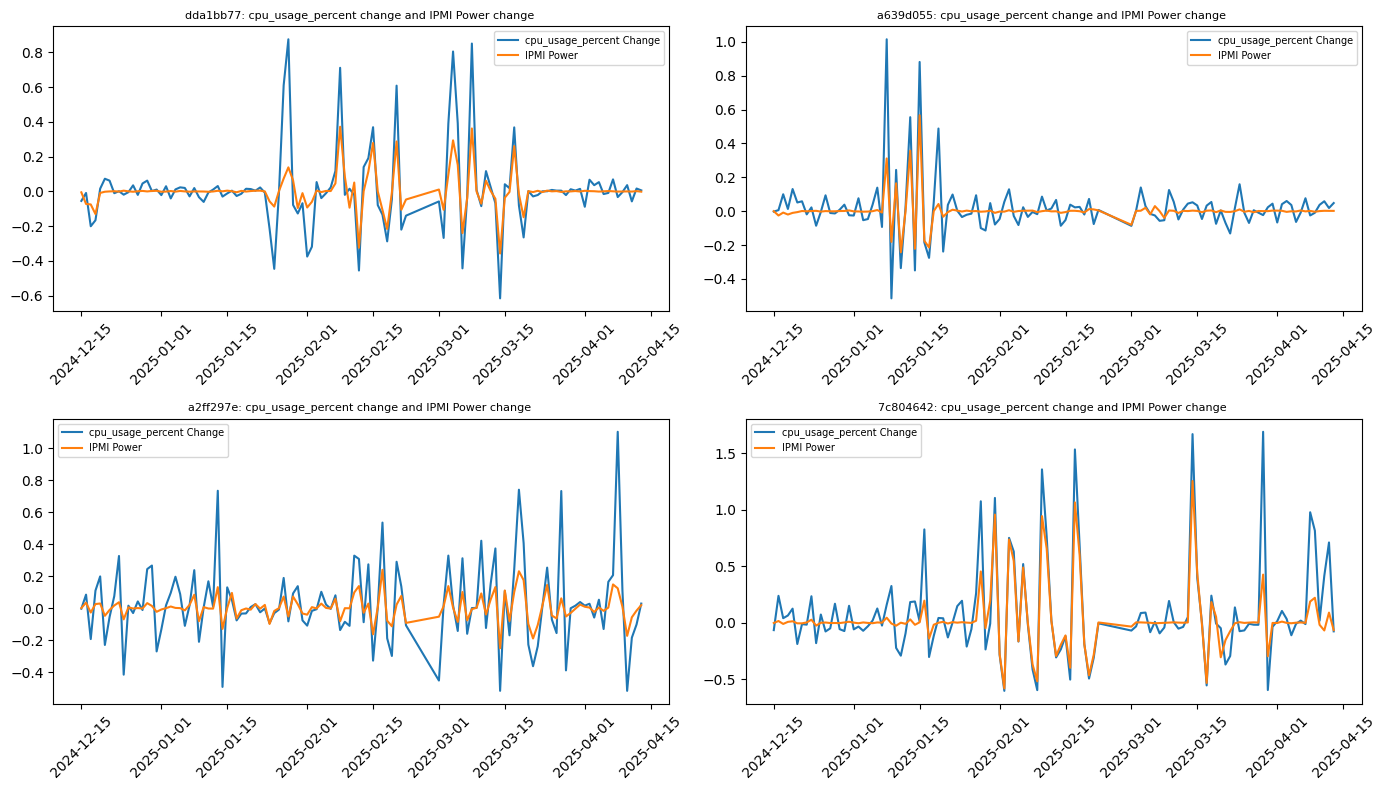

In [30]:
plot_percentage_changes("cpu_usage_percent")


### Looking at CPU USER % change and Power Consumption % Change

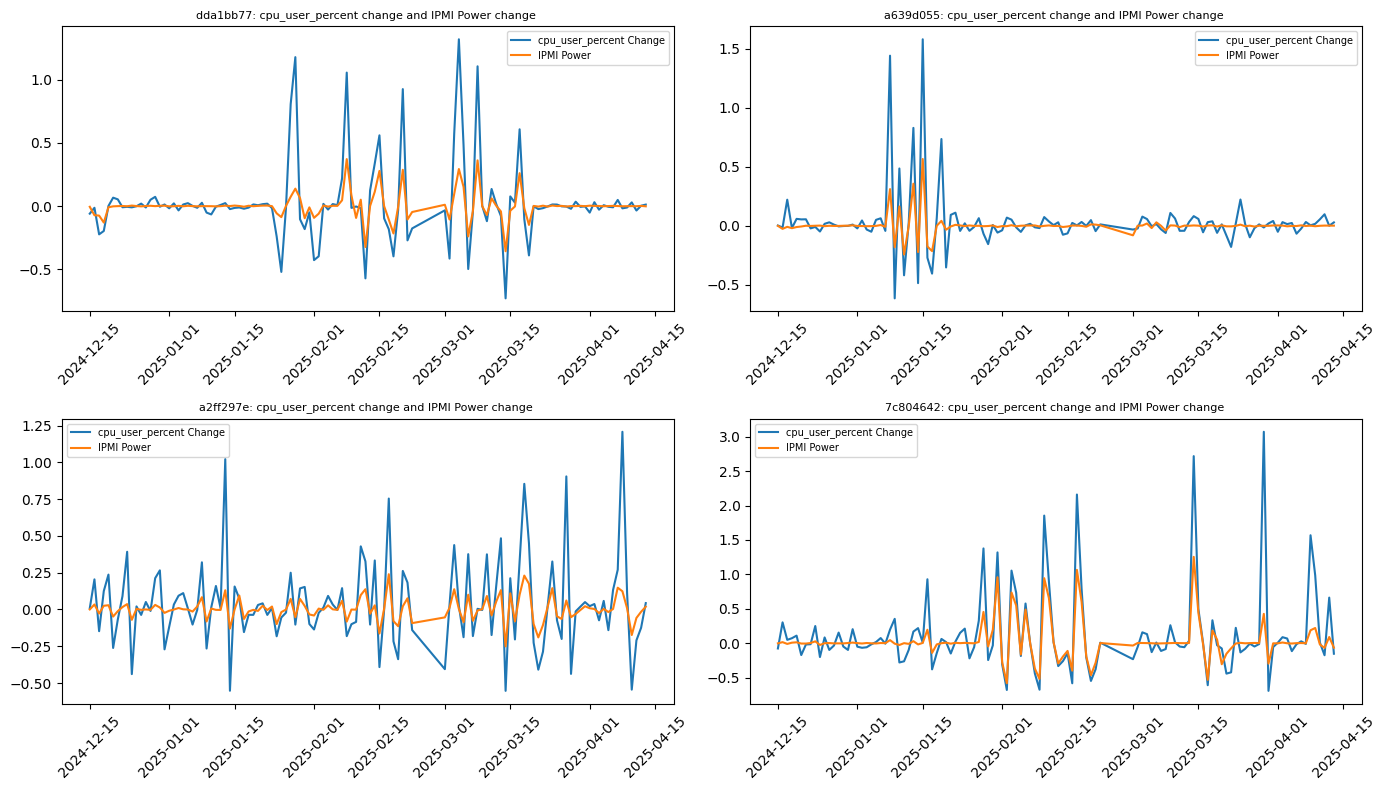

In [31]:
plot_percentage_changes("cpu_user_percent")

### Looking at Memory Used Bytes % change and Power Consumption % Change

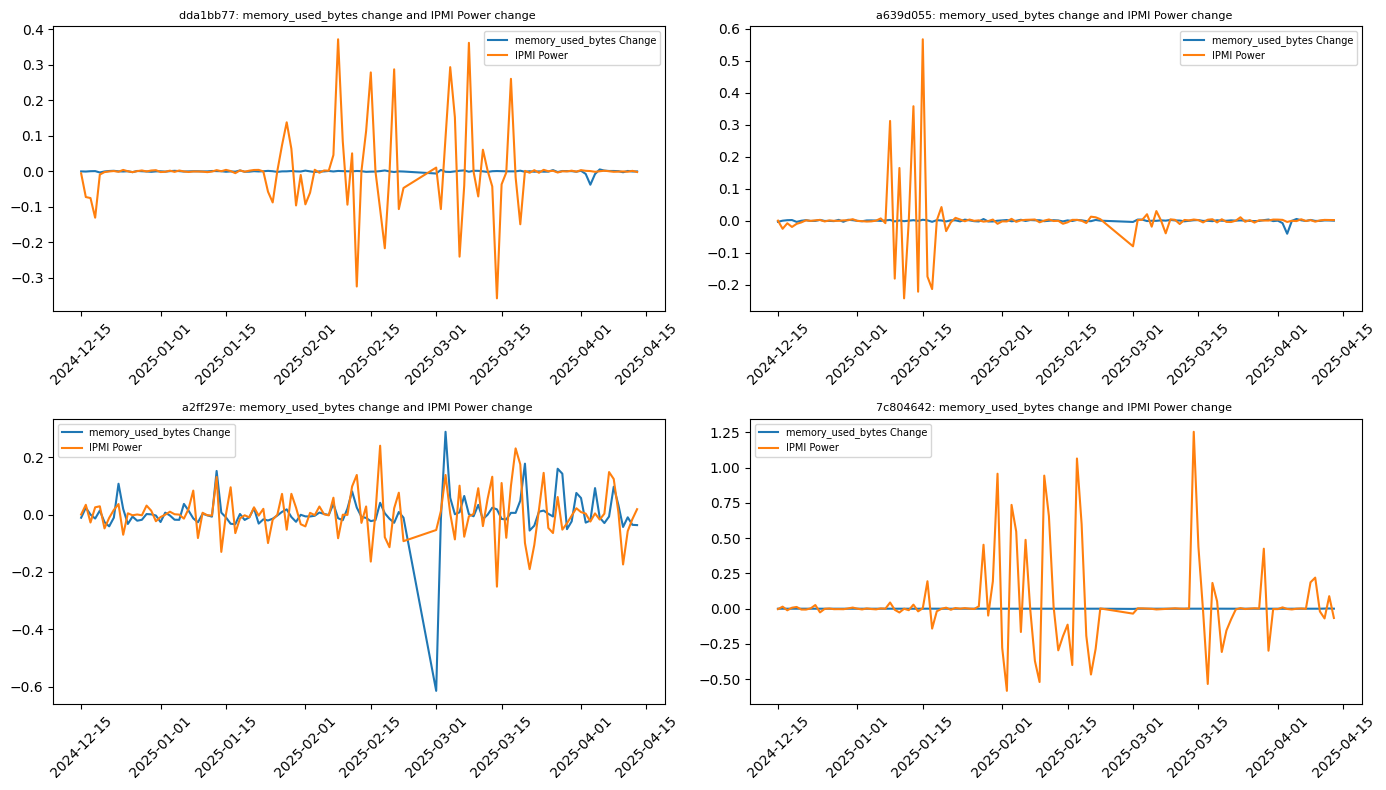

In [32]:
plot_percentage_changes("memory_used_bytes")

### Looking at Disk Used Bytes % change and Power Consumption % Change

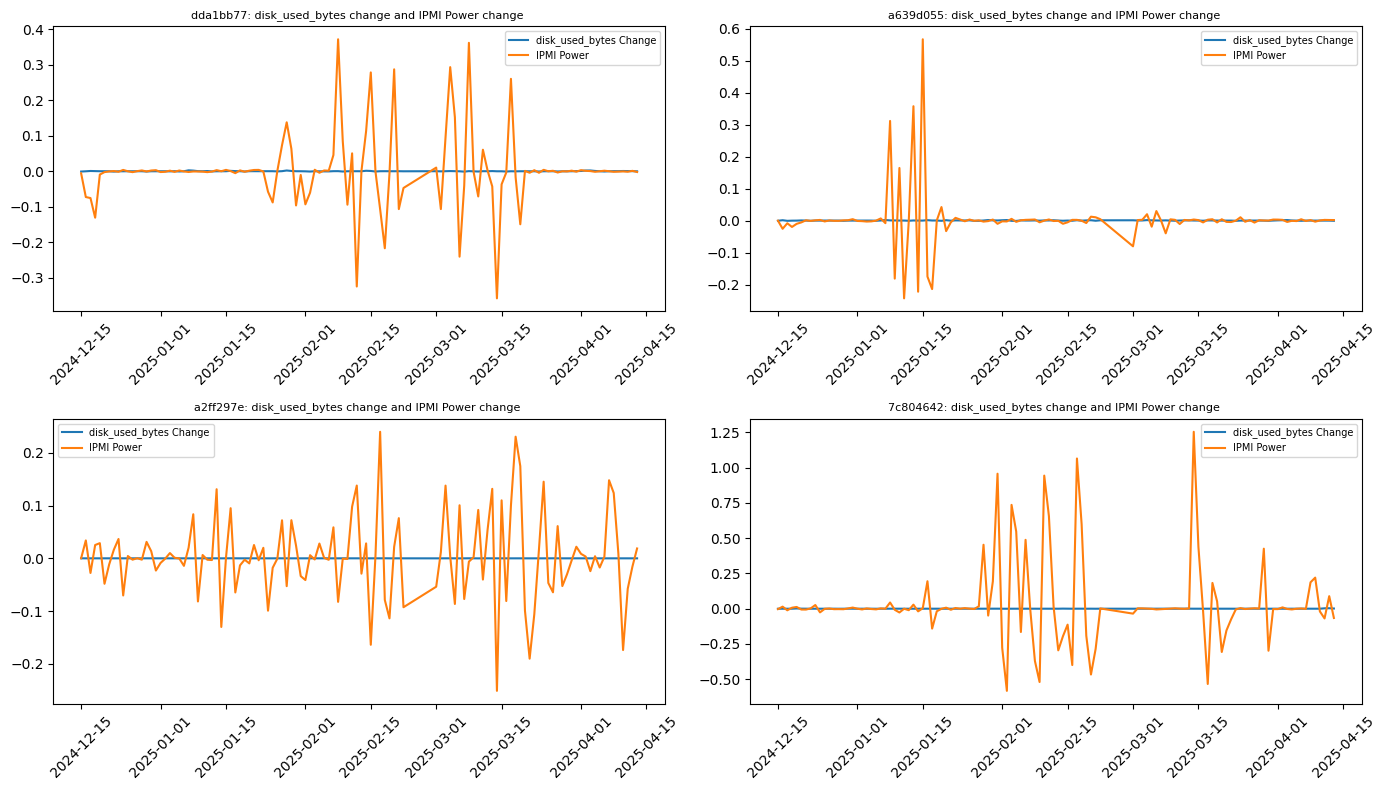

In [33]:
plot_percentage_changes("disk_used_bytes")

## Feature Engineering

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import numpy as np

In [2]:
con = duckdb.connect(':memory:')

In [3]:
duck_df = con.execute("""
    SELECT *
    FROM read_csv_auto('../datasets/cloud_energy_consumption/processed_nodes/*.csv',
                       filename=true,
                       union_by_name=true)
""").df()

node_groups = pd.read_csv('../datasets/cloud_energy_consumption/node-groups/2024-12-14T000000Z_2025-04-13T235959Z/cleaned_node_groups.csv')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [4]:
duck_df.columns

Index(['timestamp', 'node_name', 'node_group', 'cpu_usage_percent',
       'cpu_idle_percent', 'cpu_nice_percent', 'cpu_interrupt_percent',
       'cpu_softirq_percent', 'cpu_steal_percent', 'cpu_system_percent',
       'cpu_user_percent', 'cpu_wait_percent', 'load_shortterm_percent',
       'load_midterm_percent', 'load_longterm_percent', 'num_processes_total',
       'num_processes_blocked', 'num_processes_paging',
       'num_processes_running', 'num_processes_sleeping',
       'num_processes_stopped', 'num_processes_zombie', 'memory_total_bytes',
       'memory_free_bytes', 'memory_used_bytes', 'memory_buffered_bytes',
       'memory_cached_bytes', 'memory_slab_recl_bytes',
       'memory_slab_unrecl_bytes', 'disk_total_bytes', 'disk_free_bytes',
       'disk_used_bytes', 'disk_reserved_bytes', 'network_bw_rx_b/s',
       'network_bw_tx_b/s', 'ipmi_system_power_watts',
       'rapl_power_total_watts', 'scaphandre_power_total_watts',
       'ipmi_system_power_watts_imputed', 'rapl_p

In [18]:
duck_df

,timestamp,node_name,node_group,cpu_usage_percent,cpu_idle_percent,cpu_nice_percent,cpu_interrupt_percent,cpu_softirq_percent,cpu_steal_percent,cpu_system_percent,...,disk_reserved_bytes,network_bw_rx_b/s,network_bw_tx_b/s,ipmi_system_power_watts,rapl_power_total_watts,scaphandre_power_total_watts,ipmi_system_power_watts_imputed,rapl_power_total_watts_imputed,scaphandre_power_total_watts_imputed,filename
0,2024-12-14 01:00:00+01:00,366801,a6177608,0.23,99.77,0.00,0.0,0.0,0.0,0.03,...,1.822257e+09,566331.73,219964.42,404.17,261.18,NaN,404.17,261.18,0.00,../datasets/cloud_energy_consumption/processed...
1,2024-12-14 01:03:00+01:00,366801,a6177608,0.25,99.75,0.00,0.0,0.0,0.0,0.03,...,1.822257e+09,958610.48,116261.05,403.33,261.25,NaN,403.33,261.25,0.00,../datasets/cloud_energy_consumption/processed...
2,2024-12-14 01:06:00+01:00,366801,a6177608,0.24,99.76,0.00,0.0,0.0,0.0,0.03,...,1.822257e+09,718149.14,115765.61,403.33,261.05,NaN,403.33,261.05,0.00,../datasets/cloud_energy_consumption/processed...
3,2024-12-14 01:09:00+01:00,366801,a6177608,0.22,99.78,0.00,0.0,0.0,0.0,0.03,...,1.822257e+09,1329358.36,153017.73,402.5,261.25,NaN,402.50,261.25,0.00,../datasets/cloud_energy_consumption/processed...
4,2024-12-14 01:12:00+01:00,366801,a6177608,0.22,99.78,0.00,0.0,0.0,0.0,0.03,...,1.822257e+09,1076707.55,117999.27,405.0,261.17,NaN,405.00,261.17,0.00,../datasets/cloud_energy_consumption/processed...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7175995,2025-04-14 01:45:00+02:00,fe2955c5,a97fe24e,0.09,99.91,0.00,0.0,0.0,0.0,0.05,...,3.812422e+09,98225.86,8421.78,95.0,36.07,36.65,95.00,36.07,36.65,../datasets/cloud_energy_consumption/processed...
7175996,2025-04-14 01:48:00+02:00,fe2955c5,a97fe24e,0.13,99.87,0.02,0.0,0.0,0.0,0.06,...,3.812422e+09,97906.99,9488.71,88.33,35.83,36.61,88.33,35.83,36.61,../datasets/cloud_energy_consumption/processed...
7175997,2025-04-14 01:51:00+02:00,fe2955c5,a97fe24e,0.20,99.80,0.00,0.0,0.0,0.0,0.08,...,3.812422e+09,108426.82,13074.71,98.33,41.47,41.36,98.33,41.47,41.36,../datasets/cloud_energy_consumption/processed...
7175998,2025-04-14 01:54:00+02:00,fe2955c5,a97fe24e,0.09,99.91,0.00,0.0,0.0,0.0,0.05,...,3.812422e+09,93609.65,8306.80,89.17,37.14,37.33,89.17,37.14,37.33,../datasets/cloud_energy_consumption/processed...


### Reindexing nodes

In [54]:
nodes_df = duck_df.copy()

In [55]:
# print all NaN values in the ipmi_system_power_watts and ipmi_system_power_watts_imputed column
nan_power = nodes_df[nodes_df['ipmi_system_power_watts'].isna()]
print(len(nan_power))

nan_power_imputed = nodes_df[nodes_df['ipmi_system_power_watts_imputed'].isna()]
print(len(nan_power_imputed))

265874
0


In [56]:
nodes_df['timestamp'] = pd.to_datetime(nodes_df['timestamp'], utc=True)

In [57]:
# TODO: fix in the future
print(nodes_df['node_name'].isna().sum()) # having a problem with the way I had processed data that started late or ended early
nodes_df = nodes_df.dropna(subset=['node_name'])
print(nodes_df['node_name'].isna().sum())

108002
0


In [58]:
nodes_df.head(2)

,timestamp,node_name,node_group,cpu_usage_percent,cpu_idle_percent,cpu_nice_percent,cpu_interrupt_percent,cpu_softirq_percent,cpu_steal_percent,cpu_system_percent,...,disk_reserved_bytes,network_bw_rx_b/s,network_bw_tx_b/s,ipmi_system_power_watts,rapl_power_total_watts,scaphandre_power_total_watts,ipmi_system_power_watts_imputed,rapl_power_total_watts_imputed,scaphandre_power_total_watts_imputed,filename
0,2024-12-14 00:00:00+00:00,366801,a6177608,0.23,99.77,0.0,0.0,0.0,0.0,0.03,...,1.822257e+09,566331.73,219964.42,404.17,261.18,NaN,404.17,261.18,0.0,../datasets/cloud_energy_consumption/processed...
1,2024-12-14 00:03:00+00:00,366801,a6177608,0.25,99.75,0.0,0.0,0.0,0.0,0.03,...,1.822257e+09,958610.48,116261.05,403.33,261.25,NaN,403.33,261.25,0.0,../datasets/cloud_energy_consumption/processed...


In [59]:
def reindex_node(group):

    if group.empty or group['timestamp'].isna().all():
        node = group['node_name'].iloc[0] if not group.empty else '??'
        print(f"Skipping node {node}: no valid timestamps")
        
    full_index = pd.date_range(
        start=group['timestamp'].min(),
        end=group['timestamp'].max(),
        freq='3min', tz='UTC'
    )


    reindexed_group = group.set_index('timestamp').reindex(full_index).rename_axis('timestamp').reset_index() 

    return reindexed_group

In [60]:
names = nodes_df['node_name'].unique()
print(len(names))

130


In [61]:
chunks = []
for node in names: 
    temp_df = nodes_df[nodes_df['node_name'] == node]
    if temp_df.empty or temp_df['timestamp'].isna().all():
        print(f"Skipping node {node}: no valid timestamps")
        
    applied = reindex_node(temp_df)
    chunks.append(applied)

nodes = pd.concat(chunks, ignore_index=True)


In [62]:
nodes

,timestamp,node_name,node_group,cpu_usage_percent,cpu_idle_percent,cpu_nice_percent,cpu_interrupt_percent,cpu_softirq_percent,cpu_steal_percent,cpu_system_percent,...,disk_reserved_bytes,network_bw_rx_b/s,network_bw_tx_b/s,ipmi_system_power_watts,rapl_power_total_watts,scaphandre_power_total_watts,ipmi_system_power_watts_imputed,rapl_power_total_watts_imputed,scaphandre_power_total_watts_imputed,filename
0,2024-12-14 00:00:00+00:00,366801,a6177608,0.23,99.77,0.00,0.0,0.0,0.0,0.03,...,1.822257e+09,566331.73,219964.42,404.17,261.18,NaN,404.17,261.18,0.00,../datasets/cloud_energy_consumption/processed...
1,2024-12-14 00:03:00+00:00,366801,a6177608,0.25,99.75,0.00,0.0,0.0,0.0,0.03,...,1.822257e+09,958610.48,116261.05,403.33,261.25,NaN,403.33,261.25,0.00,../datasets/cloud_energy_consumption/processed...
2,2024-12-14 00:06:00+00:00,366801,a6177608,0.24,99.76,0.00,0.0,0.0,0.0,0.03,...,1.822257e+09,718149.14,115765.61,403.33,261.05,NaN,403.33,261.05,0.00,../datasets/cloud_energy_consumption/processed...
3,2024-12-14 00:09:00+00:00,366801,a6177608,0.22,99.78,0.00,0.0,0.0,0.0,0.03,...,1.822257e+09,1329358.36,153017.73,402.5,261.25,NaN,402.50,261.25,0.00,../datasets/cloud_energy_consumption/processed...
4,2024-12-14 00:12:00+00:00,366801,a6177608,0.22,99.78,0.00,0.0,0.0,0.0,0.03,...,1.822257e+09,1076707.55,117999.27,405.0,261.17,NaN,405.00,261.17,0.00,../datasets/cloud_energy_consumption/processed...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7433753,2025-04-13 23:45:00+00:00,fe2955c5,a97fe24e,0.09,99.91,0.00,0.0,0.0,0.0,0.05,...,3.812422e+09,98225.86,8421.78,95.0,36.07,36.65,95.00,36.07,36.65,../datasets/cloud_energy_consumption/processed...
7433754,2025-04-13 23:48:00+00:00,fe2955c5,a97fe24e,0.13,99.87,0.02,0.0,0.0,0.0,0.06,...,3.812422e+09,97906.99,9488.71,88.33,35.83,36.61,88.33,35.83,36.61,../datasets/cloud_energy_consumption/processed...
7433755,2025-04-13 23:51:00+00:00,fe2955c5,a97fe24e,0.20,99.80,0.00,0.0,0.0,0.0,0.08,...,3.812422e+09,108426.82,13074.71,98.33,41.47,41.36,98.33,41.47,41.36,../datasets/cloud_energy_consumption/processed...
7433756,2025-04-13 23:54:00+00:00,fe2955c5,a97fe24e,0.09,99.91,0.00,0.0,0.0,0.0,0.05,...,3.812422e+09,93609.65,8306.80,89.17,37.14,37.33,89.17,37.14,37.33,../datasets/cloud_energy_consumption/processed...


Checking null count after reindexing

In [63]:
nan_power = nodes[nodes['ipmi_system_power_watts'].isna()]
print(len(nan_power))

nan_power_imputed = nodes[nodes['ipmi_system_power_watts_imputed'].isna()]
print(len(nan_power_imputed))

631634
365760


In [64]:
len(nodes)

7433758

### Merging with node-groups

In [65]:
full_nodes_df = nodes.merge(node_groups, on='node_group', how='left')
full_nodes_df.head(5)

,timestamp,node_name,node_group,cpu_usage_percent,cpu_idle_percent,cpu_nice_percent,cpu_interrupt_percent,cpu_softirq_percent,cpu_steal_percent,cpu_system_percent,...,cpu_freq_ghz,#gpus,#disks,#ethernet_nics,#infiniband_nics,disk_size_gb,memory_size_gb,memory_used_slots,rated_power_total,rated_power_usable
0,2024-12-14 00:00:00+00:00,366801,a6177608,0.23,99.77,0.0,0.0,0.0,0.0,0.03,...,2.6,0.0,2.0,2.0,1.0,960.0,384.0,12.0,1100.0,1100.0
1,2024-12-14 00:03:00+00:00,366801,a6177608,0.25,99.75,0.0,0.0,0.0,0.0,0.03,...,2.6,0.0,2.0,2.0,1.0,960.0,384.0,12.0,1100.0,1100.0
2,2024-12-14 00:06:00+00:00,366801,a6177608,0.24,99.76,0.0,0.0,0.0,0.0,0.03,...,2.6,0.0,2.0,2.0,1.0,960.0,384.0,12.0,1100.0,1100.0
3,2024-12-14 00:09:00+00:00,366801,a6177608,0.22,99.78,0.0,0.0,0.0,0.0,0.03,...,2.6,0.0,2.0,2.0,1.0,960.0,384.0,12.0,1100.0,1100.0
4,2024-12-14 00:12:00+00:00,366801,a6177608,0.22,99.78,0.0,0.0,0.0,0.0,0.03,...,2.6,0.0,2.0,2.0,1.0,960.0,384.0,12.0,1100.0,1100.0


### Operational Features

In [66]:
# Processes
full_nodes_df['processes_util_ratio'] = full_nodes_df['num_processes_running'] / full_nodes_df['num_processes_total']

full_nodes_df['processes_blocked_ratio'] = full_nodes_df['num_processes_blocked'] / full_nodes_df['num_processes_total']

# Memory
full_nodes_df['memory_util_ratio'] = full_nodes_df['memory_used_bytes'] / full_nodes_df['memory_total_bytes']

# Disk
full_nodes_df['disk_util_ratio'] = full_nodes_df['disk_used_bytes'] / full_nodes_df['disk_total_bytes']

# Network Bandwidth
#full_nodes_df['log_net_rx'] = np.log1p(full_nodes_df['network_bw_rx_b/s'])
#full_nodes_df['log_net_tx'] = np.log1p(full_nodes_df['network_bw_tx_b/s'])

operational_features = [
    # Percentages
    'cpu_usage_percent', 'cpu_user_percent', 'cpu_idle_percent', 'cpu_system_percent', 'cpu_wait_percent', 'cpu_nice_percent', 'cpu_interrupt_percent', 
    'load_shortterm_percent', 'load_midterm_percent', 'load_longterm_percent',
    # Ratios
    'memory_util_ratio', 'disk_util_ratio', 'processes_util_ratio', 'processes_blocked_ratio',
    # Log Transformed
    #'log_net_rx', 'log_net_tx'
    ]

### Time Features

In [67]:
# Time features
# hour of day - between 0 and 23
full_nodes_df['hour'] = full_nodes_df['timestamp'].dt.hour
# day of week - where monday=0, Sunday=6
full_nodes_df['day_of_week'] = full_nodes_df['timestamp'].dt.dayofweek
# is weekend 
full_nodes_df['is_weekend'] = full_nodes_df['day_of_week'].isin([5, 6]).astype(int)

# cyclical encoding
full_nodes_df['hour_sin'] = np.sin(2 * np.pi * full_nodes_df['hour'] / 24)
full_nodes_df['hour_cos'] = np.cos(2 * np.pi * full_nodes_df['hour'] / 24)
full_nodes_df['day_of_week_sin'] = np.sin(2 * np.pi * full_nodes_df['day_of_week'] / 7)
full_nodes_df['day_of_week_cos'] = np.cos(2 * np.pi * full_nodes_df['day_of_week'] / 7)

time_features = ['hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos']

### Lag Features
For Ridge and XGBoost

In [68]:
LAG_STEPS =[1, 4, 20, 80]
TARGET = 'ipmi_system_power_watts' # then do it for ipmi_system_power_watts_imputed as well

def make_lag_features(group):
    for lag in LAG_STEPS:
        group[f'power_lag_{lag}'] = group[TARGET].shift(lag)
        group[f'cpu_lag_{lag}'] = group['cpu_usage_percent'].shift(lag)
    
    # rolling mean of target for 1 and 4 hour windows
    group[f'power_rolling_mean_20'] = group[TARGET].rolling(window=20).mean()
    group[f'power_rolling_mean_80'] = group[TARGET].rolling(window=80).mean()
    # rolling std
    group[f'power_rolling_std_20'] = group[TARGET].rolling(window=20).std()
    
    return group

In [69]:
chunks = []
for node_name, group in full_nodes_df.groupby('node_name'):
    group = make_lag_features(group)
    # dropping NaN values created by lag features - the first 80 steps per node
    chunks.append(group.iloc[80:])
full_nodes_df = pd.concat(chunks, ignore_index=True)

lag_features = ([f'power_lag_{lag}' for lag in LAG_STEPS] + 
                [f'cpu_lag_{lag}' for lag in LAG_STEPS] + 
                ['power_rolling_mean_20', 'power_rolling_mean_80', 'power_rolling_std_20'])

### Hardware Features

In [70]:
full_nodes_df['has_gpu'] = (full_nodes_df['#gpus'] > 0).astype(int)

hardware_features = ['total_threads', 'total_cores', 'rated_power_usable', 'cpu_freq_ghz', 'has_gpu']

In [71]:
others = ['timestamp', 'node_name', 'node_group', 'ipmi_system_power_watts', 'ipmi_system_power_watts_imputed']
keeping_cols = operational_features + time_features + lag_features + hardware_features + others

final_df = full_nodes_df[keeping_cols]

### Saving

In [72]:
full_nodes_df.to_csv('../datasets/cloud_energy_consumption/full_nodes_df.csv', index=False)

OSError: [Errno 28] No space left on device

## Methodology

- Experiment with imputed and not imputed results
- Also try without the reindixing which added more null values
- Train/Validation/Test Split (SORT TIMESTAMP FIRST ? or doing it for node name?)


## Linear Model

### Multiple Linear Regression

## Evaluation

## Predictors

## Forecasting with regression

## Non Linear Regression